In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine

In [ ]:
engine = create_engine(
    "postgresql+psycopg2://postgres:Your_Passwordlocalhost:5432/sales_automation"
)

print("Connected to PostgreSQL successfully!")

Connected to PostgreSQL successfully!


In [5]:
query = """
SELECT *
FROM sales;
"""

df = pd.read_sql(query, engine)

print("Data loaded successfully!")
print("Rows:", len(df))
print("Columns:", len(df.columns))

Data loaded successfully!
Rows: 9935
Columns: 14


In [6]:
df.head()


,Order_ID,Order_Date,Customer_ID,City,Product,Category,Quantity,Unit_Price,Discount_Pct,Discount_Amount,Revenue,Net_Revenue,Payment_Method,Order_Status
0,100333,2026-01-01,6139,Bengaluru,Mouse,Accessories,2,906.60,5,90.66,1813.20,1722.54,Credit Card,Shipped
1,100493,2026-01-01,5217,Delhi,Printer,Office,1,25974.74,10,2597.47,25974.74,23377.27,Debit Card,Delivered
2,100517,2026-01-01,5887,Delhi,Backpack,Accessories,3,1343.21,20,805.93,4029.63,3223.70,Cash on Delivery,Delivered
3,100577,2026-01-01,5165,Bengaluru,Mouse,Accessories,2,948.23,0,0.00,1896.46,1896.46,Debit Card,Delivered
4,100646,2026-01-01,5954,Kolkata,Tablet,Electronics,2,12699.04,0,0.00,25398.08,25398.08,Credit Card,Delivered


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9935 entries, 0 to 9934
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         9935 non-null   int64  
 1   Order_Date       9935 non-null   object 
 2   Customer_ID      9935 non-null   int64  
 3   City             9935 non-null   object 
 4   Product          9935 non-null   object 
 5   Category         9935 non-null   object 
 6   Quantity         9935 non-null   int64  
 7   Unit_Price       9935 non-null   float64
 8   Discount_Pct     9935 non-null   int64  
 9   Discount_Amount  9935 non-null   float64
 10  Revenue          9935 non-null   float64
 11  Net_Revenue      9935 non-null   float64
 12  Payment_Method   9935 non-null   object 
 13  Order_Status     9935 non-null   object 
dtypes: float64(4), int64(4), object(6)
memory usage: 1.1+ MB


In [8]:
df.isnull().sum()

Order_ID           0
Order_Date         0
Customer_ID        0
City               0
Product            0
Category           0
Quantity           0
Unit_Price         0
Discount_Pct       0
Discount_Amount    0
Revenue            0
Net_Revenue        0
Payment_Method     0
Order_Status       0
dtype: int64

#### Overall Business KPIs

In [9]:
total_orders = df["Order_ID"].nunique()
total_units = df["Quantity"].sum()
total_revenue = df["Net_Revenue"].sum()
average_order_value = total_revenue / total_orders

print("Total Orders:", total_orders)
print("Total Units Sold:", total_units)
print("Total Revenue:", round(total_revenue, 2))
print("Average Order Value:", round(average_order_value, 2))

Total Orders: 9935
Total Units Sold: 19007
Total Revenue: 330291848.97
Average Order Value: 33245.28


In [10]:
### Revenue by City
city_revenue = (
    df.groupby("City", as_index=False)
      .agg(
          total_revenue=("Net_Revenue", "sum"),
          total_orders=("Order_ID", "nunique"),
          units_sold=("Quantity", "sum")
      )
      .sort_values("total_revenue", ascending=False)
)

city_revenue

,City,total_revenue,total_orders,units_sold
4,Delhi,49436018.24,1540,2887
2,Bengaluru,46588184.98,1406,2668
10,Mumbai,44432273.32,1318,2538
11,Pune,38308068.71,1078,2074
5,Hyderabad,36326180.00,1096,2073
7,Kolkata,26867589.30,784,1557
3,Chennai,26196526.79,888,1669
0,Ahmedabad,21819886.75,671,1241
8,Lucknow,20709319.56,534,1092
6,Jaipur,18982032.22,600,1165


In [11]:
city_revenue.head(5)

,City,total_revenue,total_orders,units_sold
4,Delhi,49436018.24,1540,2887
2,Bengaluru,46588184.98,1406,2668
10,Mumbai,44432273.32,1318,2538
11,Pune,38308068.71,1078,2074
5,Hyderabad,36326180.00,1096,2073


In [12]:
### Product Analysis

product_analysis = (
    df.groupby("Product", as_index=False)
      .agg(
          total_revenue=("Net_Revenue", "sum"),
          units_sold=("Quantity", "sum"),
          orders=("Order_ID", "nunique")
      )
      .sort_values("total_revenue", ascending=False)
)

product_analysis

,Product,total_revenue,units_sold,orders
4,Laptop,97825134.68,1479,790
9,Smartphone,62760336.08,1471,797
10,Tablet,38149120.17,1472,769
5,Monitor,32444758.46,1653,852
8,Printer,27806880.89,1668,832
1,Desk,25542365.09,1746,901
7,Office Chair,16906782.09,1630,842
2,Headphones,10447950.47,1739,866
11,Webcam,8230771.21,1599,852
0,Backpack,3866139.34,1561,820


In [13]:
top_products = product_analysis.head(5)

top_products

,Product,total_revenue,units_sold,orders
4,Laptop,97825134.68,1479,790
9,Smartphone,62760336.08,1471,797
10,Tablet,38149120.17,1472,769
5,Monitor,32444758.46,1653,852
8,Printer,27806880.89,1668,832


In [14]:
### Category Analysis

category_analysis = (
    df.groupby("Category", as_index=False)
      .agg(
          total_revenue=("Net_Revenue", "sum"),
          units_sold=("Quantity", "sum"),
          orders=("Order_ID", "nunique")
      )
      .sort_values("total_revenue", ascending=False)
)

category_analysis

,Category,total_revenue,units_sold,orders
1,Electronics,2.498581e+08,9413,4926
2,Furniture,4.244915e+07,3376,1743
3,Office,2.780688e+07,1668,832
0,Accessories,1.017775e+07,4550,2434


In [15]:
### Monthly Revenue Analysis

df["Order_Date"] = pd.to_datetime(df["Order_Date"])

df["Month"] = df["Order_Date"].dt.to_period("M").astype(str)

monthly_sales = (
    df.groupby("Month", as_index=False)
      .agg(
          total_revenue=("Net_Revenue", "sum"),
          orders=("Order_ID", "nunique"),
          units_sold=("Quantity", "sum")
      )
)

monthly_sales

,Month,total_revenue,orders,units_sold
0,2026-01,35324753.54,1134,2181
1,2026-02,34970086.91,1013,1970
2,2026-03,39854574.28,1129,2238
3,2026-04,36331077.57,1121,2148
4,2026-05,38354441.35,1137,2180
5,2026-06,38389026.79,1102,2099
6,2026-07,36419507.91,1098,2099
7,2026-08,35664697.43,1121,2050
8,2026-09,34983683.19,1080,2042


In [16]:
monthly_sales.sort_values("Month")

,Month,total_revenue,orders,units_sold
0,2026-01,35324753.54,1134,2181
1,2026-02,34970086.91,1013,1970
2,2026-03,39854574.28,1129,2238
3,2026-04,36331077.57,1121,2148
4,2026-05,38354441.35,1137,2180
5,2026-06,38389026.79,1102,2099
6,2026-07,36419507.91,1098,2099
7,2026-08,35664697.43,1121,2050
8,2026-09,34983683.19,1080,2042


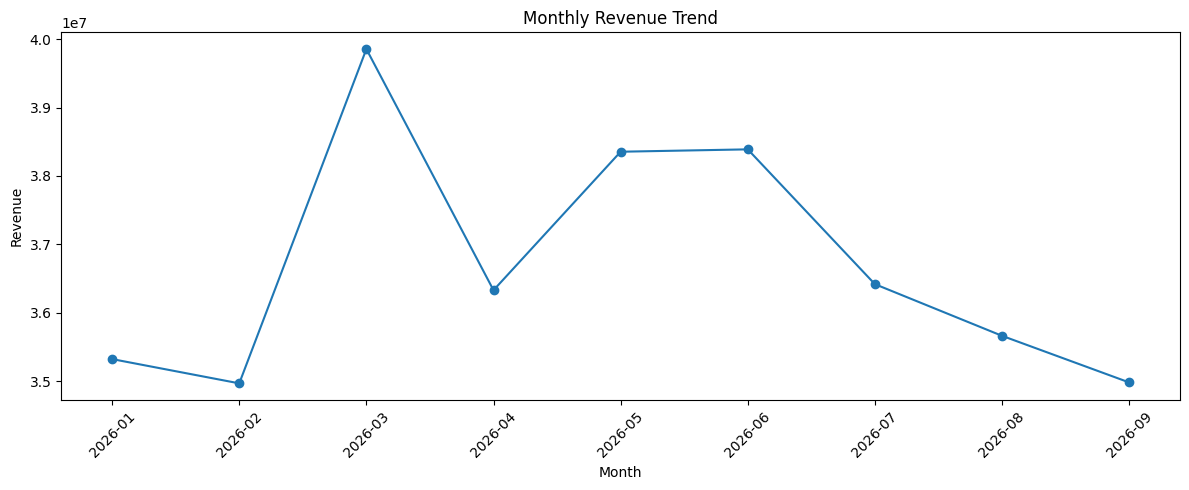

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["total_revenue"],
    marker="o"
)

plt.xlabel("Month")
plt.ylabel("Revenue")
plt.title("Monthly Revenue Trend")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [19]:
### Daily Sales Analysis
daily_sales = (
    df.groupby("Order_Date", as_index=False)
      .agg(
          total_revenue=("Net_Revenue", "sum"),
          orders=("Order_ID", "nunique"),
          units_sold=("Quantity", "sum")
      )
      .sort_values("Order_Date")
)

daily_sales.head()

,Order_Date,total_revenue,orders,units_sold
0,2026-01-01,1020743.88,38,74
1,2026-01-02,871403.34,34,65
2,2026-01-03,894656.90,30,44
3,2026-01-04,747116.03,32,64
4,2026-01-05,938089.82,35,59


In [20]:
### Payment Method Analysis

payment_analysis = (
    df.groupby("Payment_Method", as_index=False)
      .agg(
          total_revenue=("Net_Revenue", "sum"),
          orders=("Order_ID", "nunique")
      )
      .sort_values("total_revenue", ascending=False)
)

payment_analysis

,Payment_Method,total_revenue,orders
4,UPI,1.131543e+08,3415
1,Credit Card,8.552266e+07,2593
2,Debit Card,6.325113e+07,1880
3,Net Banking,4.093966e+07,1272
0,Cash on Delivery,2.742413e+07,775


In [21]:
### Order Status Analysis

status_analysis = (
    df.groupby("Order_Status", as_index=False)
      .agg(
          orders=("Order_ID", "nunique"),
          revenue=("Net_Revenue", "sum")
      )
      .sort_values("orders", ascending=False)
)

status_analysis

,Order_Status,orders,revenue
1,Delivered,7328,2.461413e+08
4,Shipped,1026,3.138828e+07
2,Processing,818,2.849516e+07
3,Returned,397,1.301926e+07
0,Cancelled,366,1.124787e+07


In [22]:
### Discount Analysis

discount_analysis = (
    df.groupby("Category", as_index=False)
      .agg(
          total_discount=("Discount_Amount", "sum"),
          total_revenue=("Net_Revenue", "sum")
      )
      .sort_values("total_discount", ascending=False)
)

discount_analysis

,Category,total_discount,total_revenue
1,Electronics,24743520.92,2.498581e+08
2,Furniture,4151065.68,4.244915e+07
3,Office,2714843.53,2.780688e+07
0,Accessories,1016866.18,1.017775e+07


In [23]:
### Find the Highest Value Transactions

top_transactions = (
    df[[
        "Order_ID",
        "Order_Date",
        "City",
        "Product",
        "Category",
        "Quantity",
        "Net_Revenue"
    ]]
    .sort_values("Net_Revenue", ascending=False)
    .head(10)
)

top_transactions

,Order_ID,Order_Date,City,Product,Category,Quantity,Net_Revenue
8726,107143,2026-08-27,Kolkata,Laptop,Electronics,5,422086.95
7900,109424,2026-08-04,Mumbai,Laptop,Electronics,5,414847.60
2812,101663,2026-03-19,Mumbai,Laptop,Electronics,5,409392.43
6084,106340,2026-06-15,Pune,Laptop,Electronics,5,397999.55
5035,108661,2026-05-18,Hyderabad,Laptop,Electronics,5,394184.79
8650,104300,2026-08-25,Pune,Laptop,Electronics,5,392893.11
9428,102409,2026-09-17,Pune,Laptop,Electronics,5,381932.85
2117,103206,2026-02-28,Kolkata,Laptop,Electronics,5,380604.40
6619,105509,2026-06-30,Hyderabad,Laptop,Electronics,5,376407.05
4701,103971,2026-05-09,Delhi,Laptop,Electronics,5,375658.65
